In [ ]:
import torch
from torch import nn
from torch import Tensor
from typing import Type


class BasicBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: int = 1,
        downsample: nn.Module = None,
    ) -> None:
        super(BasicBlock, self).__init__()
        self.downsample = downsample

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        # self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        # self.bn2   = nn.BatchNorm2d(out_channels)

    def forward(self, x: Tensor) -> Tensor:
        # identity = x
        # out = self.relu(self.bn1(self.conv1(x)))
        # out = self.bn2(self.conv2(out))
        # if self.downsample is not None:
        #     identity = self.downsample(x)
        # return self.relu(out + identity)
        identity = x
        out = self.bn1(self.conv1(x))
        if self.downsample is not None:
          identity = self.downsample(x)
        return self.relu(out + identity)


class SmallResNet(nn.Module):

    def __init__(self, num_classes: int = 2, dropout_p: float = 0.2) -> None:
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=7, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(32,  32,  blocks=1, stride=1)  # blocks=2 → 1
        self.layer2 = self._make_layer(32,  64,  blocks=1, stride=2)  # blocks=2 → 1
        self.layer3 = self._make_layer(64,  128, blocks=1, stride=2)  # blocks=2 → 1
        self.layer4 = self._make_layer(128, 256, blocks=1, stride=2)  # blocks=2 → 1

        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_p)                         # added
        self.fc      = nn.Linear(256, num_classes)

        self._init_weights()

    def _make_layer(
        self,
        in_channels: int,
        out_channels: int,
        blocks: int,
        stride: int,
    ) -> nn.Sequential:
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

        layers = [BasicBlock(in_channels, out_channels, stride, downsample)]
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: Tensor) -> Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)         # added
        return self.fc(x)


# sanity check
if __name__ == "__main__":
    model = SmallResNet(num_classes=2)
    dummy = torch.randn(4, 1, 224, 224)
    out   = model(dummy)
    print("Output shape:", out.shape)      # (4, 2)

    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {total:,}")  # ~600K

Output shape: torch.Size([4, 2])
Trainable params: 443,298


In [ ]:
!pip install opendatasets

In [ ]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia", force=True)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: maheshparajuli
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:24<00:00, 102MB/s]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import random
import os
random.seed(42)


kaggle_base = Path("/content/chest-xray-pneumonia/chest_xray/chest_xray/train")
dhuli_base = Path("/content/drive/MyDrive/dhuli_dataset-new/dhuli_dataset")
kaggle_pneumonia = kaggle_base / "PNEUMONIA"
kaggle_normal = kaggle_base / "NORMAL"
dhuli_pneumonia = dhuli_base / "pneumonia"
dhuli_normal = dhuli_base / "normal"


dataset_base = Path("/content/dataset")
normal_dest = dataset_base / "normal"
pneumonia_dest = dataset_base / "pneumonia"


def clean_dir(path):
    if path.exists():
        for f in path.glob("*"):
            f.unlink()
    path.mkdir(parents=True, exist_ok=True)

clean_dir(normal_dest)
clean_dir(pneumonia_dest)


def get_images(path):
    return [p for p in path.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]


def link_images(images, dest, prefix):
    for img in images:
        try:
            target = dest / f"{prefix}_{img.name}"
            if not target.exists():
                os.symlink(img, target)
        except:
            continue

kp_images = get_images(kaggle_pneumonia)
kn_images = get_images(kaggle_normal)
dp_images = get_images(dhuli_pneumonia)
dn_images = get_images(dhuli_normal)


if len(kp_images) < 1000:
    raise ValueError(f"Not enough pneumonia images in Kaggle. Found {len(kp_images)}, needed 1000.")
if len(kn_images) < 500:
    raise ValueError(f"Not enough normal images in Kaggle. Found {len(kn_images)}, needed 500.")


kp_selected = random.sample(kp_images, 1000)
kn_selected = random.sample(kn_images, 500)


link_images(kp_selected, pneumonia_dest, "kaggle")
link_images(dp_images, pneumonia_dest, "dhuli")
link_images(kn_selected, normal_dest, "kaggle")
link_images(dn_images, normal_dest, "dhuli")


print("========== Dataset Summary ==========")
print(f"  Kaggle Pneumonia (selected) : {len(kp_selected)}")
print(f"  Kaggle Normal    (selected) : {len(kn_selected)}")
print(f"  Dhuli  Pneumonia (all)      : {len(dp_images)}")
print(f"  Dhuli  Normal    (all)      : {len(dn_images)}")
print("-------------------------------------")
print(f"  Total Pneumonia in dataset  : {len(list(pneumonia_dest.glob('*')))}")
print(f"  Total Normal    in dataset  : {len(list(normal_dest.glob('*')))}")
print("=====================================")

========== Dataset Summary ==========
  Kaggle Pneumonia (selected) : 1000
  Kaggle Normal    (selected) : 500
  Dhuli  Pneumonia (all)      : 161
  Dhuli  Normal    (all)      : 617
-------------------------------------
  Total Pneumonia in dataset  : 1161
  Total Normal    in dataset  : 1117


In [ ]:
from pathlib import Path

main_data_total = Path("/content/dataset")

train_dir = main_data_total


In [ ]:
# from torchvision import datasets, transforms
# from torch.utils.data import DataLoader
# import torch

# transform = transforms.Compose([
#     transforms.Grayscale(num_output_channels=1),
#      transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# dataset = datasets.ImageFolder(
#     root=train_dir,
#     transform=transform
# )

# loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

# mean = 0.0
# std = 0.0
# total_images = 0

# for images, _ in loader:
#     batch_samples = images.size(0)
#     images = images.view(batch_samples, images.size(1), -1)

#     mean += images.mean(2).sum(0)
#     std += images.std(2).sum(0)
#     total_images += batch_samples

# mean /= total_images
# std /= total_images

# print("Mean:", mean)
# print("Std:", std)

Mean: tensor([0.4755])
Std: tensor([0.2145])


In [ ]:
import torchvision.transforms as transforms
from torchvision.transforms import functional as F
import torch
import numpy as np



train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=1),

    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.1,
        scale=(0.02, 0.1),
        ratio=(0.3, 3.3),
        value=0,
    ),

    transforms.Normalize(
        mean=[0.4755],
        std=[0.2145],
    ),
])


# ─────────────────────────────────────────────
#  VAL / TEST TRANSFORMS
#  — NO augmentation (we want real performance)
#  — only resize + normalize (same as train normalize)
# ─────────────────────────────────────────────
val_test_transforms = transforms.Compose([

    # 1. Resize — same size as training
    transforms.Resize((224, 224)),

    # 1. Random Gaussian Blur — simulates image quality variation
# transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5)),

# 2. Random Sharpness — simulates different scanner sharpness
# transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
    # 2. Grayscale — keep single channel
    transforms.Grayscale(num_output_channels=1), #####

    # 3. ToTensor — convert PIL image to tensor [0, 1]
    transforms.ToTensor(),

    # # 4. Normalize — MUST use exact same values as train  #####
     transforms.Normalize(
        mean=[0.4755],
        std=[0.2145],
    ),
])


In [ ]:
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=train_transforms,

                                  )

In [ ]:
train_data.classes

['normal', 'pneumonia']

In [ ]:
train_data.class_to_idx

{'normal': 0, 'pneumonia': 1}

In [ ]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [ ]:
import os
ra=os.cpu_count()
ra

2

In [ ]:
import requests
from pathlib import Path

# Download helper function from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download...")

else:
  print("Downloading helper function...")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)



### Functionizing training and evaluation/testing loops
let's create a function for:
* training loop - `train_step()`
* testing loop - `test_step()`

In [ ]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)


    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [ ]:
def val_step(model: torch.nn.Module,
             dataloader: torch.utils.data.DataLoader,
             loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup val loss and val accuracy values
    val_loss, val_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            val_pred_logits = model(X)
            # 2. Calculate and accumulate loss
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()

            # Calculate and accumulate accuracy
            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item()/len(val_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc

In [ ]:
# from tqdm.auto import tqdm

# def train(model: torch.nn.Module,
#           train_dataloader: torch.utils.data.DataLoader,
#           val_dataloader: torch.utils.data.DataLoader,
#           optimizer: torch.optim.Optimizer,
#           loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
#           epochs: int = 5,
#           scheduler: torch.optim.lr_scheduler.LRScheduler = None):

#     results = {"train_loss": [],
#                "train_acc": [],
#                "val_loss": [],
#                "val_acc": []}

#     for epoch in tqdm(range(epochs)):
#         train_loss, train_acc = train_step(
#             model=model,
#             dataloader=train_dataloader,
#             loss_fn=loss_fn,
#             optimizer=optimizer
#         )
#         val_loss, val_acc = val_step(
#             model=model,
#             dataloader=val_dataloader,
#             loss_fn=loss_fn
#         )

#         # ← scheduler steps once per epoch here
#         if scheduler is not None:
#             scheduler.step()

#         # ← shows LR changing each epoch
#         current_lr = optimizer.param_groups[0]['lr']

#         print(
#             f"Epoch: {epoch+1} | "
#             f"train_loss: {train_loss:.4f} | "
#             f"train_acc: {train_acc:.4f} | "
#             f"val_loss: {val_loss:.4f} | "
#             f"val_acc: {val_acc:.4f} | "
#             f"lr: {current_lr:.6f}"  # ← added
#         )

#         results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
#         results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
#         results["val_loss"].append(val_loss.item() if isinstance(val_loss, torch.Tensor) else val_loss)
#         results["val_acc"].append(val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc)

#     return results


In [ ]:
import copy
from tqdm.auto import tqdm

def train(model, train_dataloader, val_dataloader,
          optimizer, loss_fn=nn.CrossEntropyLoss(),
          epochs=5, scheduler=None, patience=None):

    results = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}

    best_val_acc = 0.0
    best_weights = None
    epochs_no_improve = 0

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model, dataloader=train_dataloader,
            loss_fn=loss_fn, optimizer=optimizer)

        val_loss, val_acc = val_step(
            model=model, dataloader=val_dataloader,
            loss_fn=loss_fn)

        # Capture LR before stepping (shows LR used this epoch)
        current_lr = optimizer.param_groups[0]['lr']

        if scheduler is not None:
            scheduler.step()

        # Save best weights
        val_acc_val = val_acc.item() if isinstance(val_acc, torch.Tensor) else val_acc
        if val_acc_val > best_val_acc:
            best_val_acc = val_acc_val
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | "
              f"lr: {current_lr:.6f}")

        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item()  if isinstance(train_acc,  torch.Tensor) else train_acc)
        results["val_loss"].append(val_loss.item()    if isinstance(val_loss,   torch.Tensor) else val_loss)
        results["val_acc"].append(val_acc_val)

        # Early stopping
        if patience and epochs_no_improve >= patience:
            print(f"  Early stopping triggered at epoch {epoch+1}")
            break

    # Restore best weights before returning
    if best_weights is not None:
        model.load_state_dict(best_weights)
        print(f"  Restored best weights (val_acc: {best_val_acc*100:.2f}%)")

    return results

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Subset
from timeit import default_timer as timer
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import numpy as np
import copy

# ─────────────────────────────────────────────
# INSTALL & IMPORT FLOP COUNTER
# ─────────────────────────────────────────────
try:
    from thop import profile, clever_format
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "thop", "-q"])
    from thop import profile, clever_format

# ─────────────────────────────────────────────
# K-FOLD SETTINGS
# ─────────────────────────────────────────────
K             = 5
NUM_EPOCHS    = 25
WARMUP_EPOCHS = 3
BATCH_SIZE    = 8

# ─────────────────────────────────────────────
# TWO DATASET OBJECTS — no leakage
# ─────────────────────────────────────────────
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=train_dir, transform=val_test_transforms)
base_dataset  = datasets.ImageFolder(root=train_dir)  # no transform, for labels only

all_labels = [label for _, label in base_dataset]
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

# ─────────────────────────────────────────────
# MODEL PROFILE
# ─────────────────────────────────────────────
_dummy_model = SmallResNet().to(device)
_dummy_input = torch.randn(1, 1, 224, 224).to(device)  # 1 channel grayscale

_flops, _params = profile(_dummy_model, inputs=(_dummy_input,), verbose=False)
flops_str, params_str = clever_format([_flops, _params], "%.3f")

total_params     = sum(p.numel() for p in _dummy_model.parameters())
trainable_params = sum(p.numel() for p in _dummy_model.parameters() if p.requires_grad)

del _dummy_model, _dummy_input

print(f"\n{'='*60}")
print(f"  MODEL PROFILE")
print(f"{'='*60}")
print(f"  Total Parameters     : {total_params:,}")
print(f"  Trainable Parameters : {trainable_params:,}")
print(f"  Non-trainable Params : {total_params - trainable_params:,}")
print(f"  FLOPs                : {flops_str}")
print(f"{'='*60}")

# ─────────────────────────────────────────────
# EVALUATE METRICS
# ─────────────────────────────────────────────
def evaluate_metrics(model, dataloader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            probs  = torch.softmax(logits, dim=1)[:, 1]
            preds  = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    pre = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1  = f1_score(all_labels, all_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0

    return acc, pre, rec, f1, auc

# ─────────────────────────────────────────────
# STORAGE
# ─────────────────────────────────────────────
fold_results     = []
fold_precisions  = []
fold_recalls     = []
fold_f1s         = []
fold_aucs        = []
fold_train_times = []
all_fold_curves  = []

best_val_acc_overall = 0.0
best_fold            = 0

# ─────────────────────────────────────────────
# K-FOLD LOOP
# ─────────────────────────────────────────────
start_time = timer()

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(all_labels)), all_labels)):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold+1}/{K}")
    print(f"{'='*60}")

    # ── Subsets — correct transforms per split ──
    train_subset = Subset(train_dataset, train_idx)
    val_subset   = Subset(val_dataset,   val_idx)

    # ── Dataloaders ───────────────────────────
    train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_subset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"  Train samples : {len(train_subset)}")
    print(f"  Val samples   : {len(val_subset)}")

    # ── Fresh model per fold ──────────────────
    torch.manual_seed(42)
    torch.cuda.manual_seed(42)
    model = SmallResNet().to(device)

    # ── Loss & Optimizer ──────────────────────
    loss_fn   = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=3e-4,
        weight_decay=1e-2
    )

    # ── Schedulers ────────────────────────────
    warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=WARMUP_EPOCHS
    )
    cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS - WARMUP_EPOCHS,
        eta_min=1e-6
    )
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[WARMUP_EPOCHS]
    )

    # ── Train ─────────────────────────────────
    fold_start = timer()
    results = train(
        model=model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=NUM_EPOCHS,
        scheduler=scheduler
    )
    fold_end  = timer()
    fold_time = fold_end - fold_start
    fold_train_times.append(fold_time)
    all_fold_curves.append(results)

    # ── Restore best epoch weights before evaluation ──
    best_epoch_idx = results['val_acc'].index(max(results['val_acc']))
    print(f"  Best epoch : {best_epoch_idx+1} "
          f"(val_acc={max(results['val_acc'])*100:.2f}%)")

    # ── Evaluate all metrics on val set ───────
    acc, pre, rec, f1, auc = evaluate_metrics(model, val_loader, device)
    fold_results.append(acc)
    fold_precisions.append(pre)
    fold_recalls.append(rec)
    fold_f1s.append(f1)
    fold_aucs.append(auc)

    print(f"\n  Fold {fold+1} Results:")
    print(f"    Acc  : {acc*100:.2f}%")
    print(f"    Pre  : {pre*100:.2f}%")
    print(f"    Rec  : {rec*100:.2f}%")
    print(f"    F1   : {f1*100:.2f}%")
    print(f"    AUC  : {auc*100:.2f}%")
    print(f"    Time : {fold_time/60:.2f} min ({fold_time:.1f} sec)")

    if acc > best_val_acc_overall:
        best_val_acc_overall = acc
        best_fold            = fold + 1
        print(f"   New best fold! Fold {best_fold} | Acc: {acc*100:.2f}%")

end_time   = timer()
total_time = end_time - start_time

# ─────────────────────────────────────────────
# REPORT TABLE
# ─────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"  Results of {K}-Fold Cross-Validation — SmallResNet (Chest X-Ray)")
print(f"{'='*75}")
print(f"  {'Fold':<14} {'Acc(%)':>9} {'Pre(%)':>9} {'Rec(%)':>9} {'F1(%)':>9} {'AUC(%)':>9}")
print(f"  {'-'*61}")
for i in range(K):
    marker = " ◄" if (i + 1) == best_fold else ""
    print(f"  {str(i+1):<14}"
          f" {fold_results[i]*100:>8.2f}"
          f" {fold_precisions[i]*100:>9.2f}"
          f" {fold_recalls[i]*100:>9.2f}"
          f" {fold_f1s[i]*100:>9.2f}"
          f" {fold_aucs[i]*100:>9.2f}{marker}")
print(f"  {'-'*61}")
print(f"  {'Avg±Std. Dev.':<14}"
      f" {np.mean(fold_results)*100:>6.2f}±{np.std(fold_results)*100:<4.2f}"
      f" {np.mean(fold_precisions)*100:>6.2f}±{np.std(fold_precisions)*100:<4.2f}"
      f" {np.mean(fold_recalls)*100:>6.2f}±{np.std(fold_recalls)*100:<4.2f}"
      f" {np.mean(fold_f1s)*100:>6.2f}±{np.std(fold_f1s)*100:<4.2f}"
      f" {np.mean(fold_aucs)*100:>6.2f}±{np.std(fold_aucs)*100:<4.2f}")
print(f"{'='*75}")
print(f"  Avg: average  Std.Dev: Standard Deviation")

# ─────────────────────────────────────────────
# PANDAS TABLE
# ─────────────────────────────────────────────
import pandas as pd

rows = {
    "Fold"   : [f"Fold {i+1}" for i in range(K)],
    "Acc(%)" : [round(a*100, 2) for a in fold_results],
    "Pre(%)" : [round(p*100, 2) for p in fold_precisions],
    "Rec(%)" : [round(r*100, 2) for r in fold_recalls],
    "F1(%)"  : [round(f*100, 2) for f in fold_f1s],
    "AUC(%)" : [round(a*100, 2) for a in fold_aucs],
}
avg_row = {
    "Fold"   : "Avg±Std",
    "Acc(%)" : f"{np.mean(fold_results)*100:.2f}±{np.std(fold_results)*100:.2f}",
    "Pre(%)" : f"{np.mean(fold_precisions)*100:.2f}±{np.std(fold_precisions)*100:.2f}",
    "Rec(%)" : f"{np.mean(fold_recalls)*100:.2f}±{np.std(fold_recalls)*100:.2f}",
    "F1(%)"  : f"{np.mean(fold_f1s)*100:.2f}±{np.std(fold_f1s)*100:.2f}",
    "AUC(%)" : f"{np.mean(fold_aucs)*100:.2f}±{np.std(fold_aucs)*100:.2f}",
}
df = pd.DataFrame(rows)
df = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)
display(df)
df.to_excel("kfold_results.xlsx", index=False)

# ─────────────────────────────────────────────
# TRAINING TIME & MODEL COMPLEXITY
# ─────────────────────────────────────────────
print(f"\n{'='*75}")
print(f"  TRAINING TIME SUMMARY")
print(f"{'='*75}")
for i, t in enumerate(fold_train_times):
    print(f"  Fold {i+1} : {t/60:.2f} min ({t:.1f} sec)")
print(f"  {'-'*40}")
print(f"  Average : {np.mean(fold_train_times)/60:.2f} min")
print(f"  Total   : {total_time/60:.2f} min ({total_time:.1f} sec)")
print(f"{'='*75}")

print(f"\n{'='*75}")
print(f"  MODEL COMPLEXITY SUMMARY")
print(f"{'='*75}")
print(f"  Total Parameters     : {total_params:,}")
print(f"  Trainable Parameters : {trainable_params:,}")
print(f"  Non-trainable Params : {total_params - trainable_params:,}")
print(f"  FLOPs                : {flops_str}")
print(f"{'='*75}")


  MODEL PROFILE
  Total Parameters     : 443,298
  Trainable Parameters : 443,298
  Non-trainable Params : 0
  FLOPs                : 388.355M

  FOLD 1/5
  Train samples : 1822
  Val samples   : 456


  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6553 | train_acc: 0.6118 | val_loss: 0.6201 | val_acc: 0.5789 | lr: 0.000030
Epoch: 2 | train_loss: 0.5675 | train_acc: 0.7277 | val_loss: 0.4228 | val_acc: 0.8158 | lr: 0.000120
Epoch: 3 | train_loss: 0.4970 | train_acc: 0.7666 | val_loss: 0.4358 | val_acc: 0.7982 | lr: 0.000210
Epoch: 4 | train_loss: 0.4871 | train_acc: 0.7820 | val_loss: 0.3865 | val_acc: 0.8158 | lr: 0.000300
Epoch: 5 | train_loss: 0.4224 | train_acc: 0.8152 | val_loss: 0.4789 | val_acc: 0.7675 | lr: 0.000298
Epoch: 6 | train_loss: 0.4168 | train_acc: 0.8196 | val_loss: 0.3488 | val_acc: 0.8421 | lr: 0.000294
Epoch: 7 | train_loss: 0.4137 | train_acc: 0.8291 | val_loss: 0.4234 | val_acc: 0.8158 | lr: 0.000286
Epoch: 8 | train_loss: 0.3737 | train_acc: 0.8452 | val_loss: 0.3765 | val_acc: 0.7807 | lr: 0.000276
Epoch: 9 | train_loss: 0.3703 | train_acc: 0.8448 | val_loss: 0.2470 | val_acc: 0.9079 | lr: 0.000263
Epoch: 10 | train_loss: 0.3549 | train_acc: 0.8485 | val_loss: 0.2653 | val_acc: 0

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6572 | train_acc: 0.6122 | val_loss: 0.5949 | val_acc: 0.6513 | lr: 0.000030
Epoch: 2 | train_loss: 0.5676 | train_acc: 0.7228 | val_loss: 0.4597 | val_acc: 0.8180 | lr: 0.000120
Epoch: 3 | train_loss: 0.4906 | train_acc: 0.7805 | val_loss: 0.5065 | val_acc: 0.6645 | lr: 0.000210
Epoch: 4 | train_loss: 0.4677 | train_acc: 0.7776 | val_loss: 0.4665 | val_acc: 0.7171 | lr: 0.000300
Epoch: 5 | train_loss: 0.4198 | train_acc: 0.8112 | val_loss: 2.0351 | val_acc: 0.5351 | lr: 0.000298
Epoch: 6 | train_loss: 0.4255 | train_acc: 0.8092 | val_loss: 0.3863 | val_acc: 0.8180 | lr: 0.000294
Epoch: 7 | train_loss: 0.4024 | train_acc: 0.8273 | val_loss: 0.5504 | val_acc: 0.7325 | lr: 0.000286
Epoch: 8 | train_loss: 0.3812 | train_acc: 0.8405 | val_loss: 0.2781 | val_acc: 0.8947 | lr: 0.000276
Epoch: 9 | train_loss: 0.3582 | train_acc: 0.8527 | val_loss: 0.3441 | val_acc: 0.8443 | lr: 0.000263
Epoch: 10 | train_loss: 0.3531 | train_acc: 0.8582 | val_loss: 0.6918 | val_acc: 0

...

Epoch: 1 | train_loss: 0.6534 | train_acc: 0.6176 | val_loss: 0.5865 | val_acc: 0.6535 | lr: 0.000030
Epoch: 2 | train_loss: 0.5749 | train_acc: 0.6960 | val_loss: 0.4310 | val_acc: 0.7895 | lr: 0.000120
Epoch: 3 | train_loss: 0.5035 | train_acc: 0.7733 | val_loss: 0.5283 | val_acc: 0.7845 | lr: 0.000210
Epoch: 4 | train_loss: 0.4829 | train_acc: 0.7796 | val_loss: 0.5573 | val_acc: 0.7892 | lr: 0.000300
Epoch: 5 | train_loss: 0.4420 | train_acc: 0.8014 | val_loss: 0.3284 | val_acc: 0.8596 | lr: 0.000298
Epoch: 6 | train_loss: 0.4245 | train_acc: 0.8279 | val_loss: 0.3847 | val_acc: 0.8528 | lr: 0.000294
Epoch: 7 | train_loss: 0.4046 | train_acc: 0.8158 | val_loss: 0.5578 | val_acc: 0.7754 | lr: 0.000286
Epoch: 8 | train_loss: 0.3980 | train_acc: 0.8228 | val_loss: 0.3081 | val_acc: 0.8835 | lr: 0.000276
Epoch: 9 | train_loss: 0.3765 | train_acc: 0.8387 | val_loss: 0.4601 | val_acc: 0.8352 | lr: 0.000263
Epoch: 10 | train_loss: 0.3669 | train_acc: 0.8392 | val_loss: 0.4135 | val_acc: 0

  0%|          | 0/25 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.6518 | train_acc: 0.6270 | val_loss: 0.6074 | val_acc: 0.6162 | lr: 0.000030
Epoch: 2 | train_loss: 0.5578 | train_acc: 0.7180 | val_loss: 0.5191 | val_acc: 0.7171 | lr: 0.000120
Epoch: 3 | train_loss: 0.4801 | train_acc: 0.7686 | val_loss: 0.7196 | val_acc: 0.7290 | lr: 0.000210
Epoch: 4 | train_loss: 0.4469 | train_acc: 0.7960 | val_loss: 0.6105 | val_acc: 0.7641 | lr: 0.000300
Epoch: 5 | train_loss: 0.4477 | train_acc: 0.8014 | val_loss: 0.3642 | val_acc: 0.8637 | lr: 0.000298
Epoch: 6 | train_loss: 0.4117 | train_acc: 0.8212 | val_loss: 0.4231 | val_acc: 0.8543 | lr: 0.000294
Epoch: 7 | train_loss: 0.4011 | train_acc: 0.8235 | val_loss: 0.5862 | val_acc: 0.7747 | lr: 0.000286
Epoch: 8 | train_loss: 0.3918 | train_acc: 0.8337 | val_loss: 0.3038 | val_acc: 0.8750 | lr: 0.000276
Epoch: 9 | train_loss: 0.3629 | train_acc: 0.8497 | val_loss: 0.3134 | val_acc: 0.8882 | lr: 0.000263
Epoch: 10 | train_loss: 0.3513 | train_acc: 0.8519 | val_loss: 0.2921 | val_acc: 0

,Fold,Acc(%),Pre(%),Rec(%),F1(%),AUC(%)
0,Fold 1,93.42,93.53,93.53,93.53,97.68
1,Fold 2,92.76,93.83,91.81,92.81,97.14
2,Fold 3,93.42,93.94,93.13,93.53,97.87
3,Fold 4,92.97,98.54,87.5,92.69,97.46
4,Fold 5,93.19,93.51,93.1,93.3,97.25
5,Avg±Std,93.15±0.26,94.67±1.94,91.82±2.23,93.18±0.36,97.48±0.27



  TRAINING TIME SUMMARY
  Fold 1 : 27.90 min (1673.8 sec)
  Fold 2 : 27.77 min (1666.5 sec)
  Fold 3 : 27.34 min (1640.2 sec)
  Fold 4 : 27.88 min (1673.0 sec)
  Fold 5 : 27.38 min (1642.8 sec)
  ----------------------------------------
  Average : 27.65 min
  Total   : 139.29 min (8357.4 sec)

  MODEL COMPLEXITY SUMMARY
  Total Parameters     : 443,298
  Trainable Parameters : 443,298
  Non-trainable Params : 0
  FLOPs                : 388.355M


In [ ]:

# from torch.utils.data import DataLoader
# from timeit import default_timer as timer
# import copy
# NUM_EPOCHS    = 25
# WARMUP_EPOCHS = 3
# BATCH_SIZE    = 32

# print(f"\n{'='*60}")
# print(f"  FULL DATASET TRAINING")
# print(f"{'='*60}")

# # ── Dataset & Dataloader ──────────────────────
# full_train_dataset = datasets.ImageFolder(
#     root=train_dir,
#     transform=train_transforms
# )

# full_train_loader = DataLoader(
#     full_train_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     # num_workers=2
# )

# print(f"  Total training samples : {len(full_train_dataset)}")

# # ── Fresh model ───────────────────────────────
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)
# final_model = SmallResNet().to(device)

# # ── Loss & Optimizer ──────────────────────────
# loss_fn   = nn.CrossEntropyLoss()
# optimizer = torch.optim.AdamW(
#     final_model.parameters(),
#     lr=3e-4,
#     weight_decay=1e-2
# )

# # ── Schedulers ────────────────────────────────
# warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
#     optimizer,
#     start_factor=0.1,
#     end_factor=1.0,
#     total_iters=WARMUP_EPOCHS
# )
# cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=NUM_EPOCHS - WARMUP_EPOCHS,
#     eta_min=1e-6
# )
# scheduler = torch.optim.lr_scheduler.SequentialLR(
#     optimizer,
#     schedulers=[warmup_scheduler, cosine_scheduler],
#     milestones=[WARMUP_EPOCHS]
# )

# # ── Train loop (no validation) ────────────────
# full_start = timer()

# for epoch in range(NUM_EPOCHS):
#     train_loss, train_acc = train_step(
#         model=final_model,
#         dataloader=full_train_loader,
#         loss_fn=loss_fn,
#         optimizer=optimizer
#     )
#     scheduler.step()
#     current_lr = optimizer.param_groups[0]['lr']

#     print(
#         f"Epoch: {epoch+1}/{NUM_EPOCHS} | "
#         f"train_loss: {train_loss:.4f} | "
#         f"train_acc: {train_acc:.4f} | "
#         f"lr: {current_lr:.6f}"
#     )

# full_time = timer() - full_start
# print(f"\n  Full training time : {full_time/60:.2f} min ({full_time:.1f} sec)")

# # ─────────────────────────────────────────────
# # SAVE MODEL
# # ─────────────────────────────────────────────
# torch.save({
#     'model_state_dict' : final_model.state_dict(),
#     'model_name'       : 'SmallResNet',
#     'num_epochs'       : NUM_EPOCHS,
#     'optimizer'        : str(optimizer.__class__.__name__),
#     # 'total_params'     : total_params,
#     'flops'            : flops_str,
#     'train_samples'    : len(full_train_dataset),
# }, 'smallresnet_final.pth')

# print(f"\n  Model saved to : smallresnet_final.pth")

# # Download on Colab
# from google.colab import files
# files.download('smallresnet_final.pth')

# # ─────────────────────────────────────────────
# # LOAD MODEL & TEST ON UNSEEN DATA
# # ─────────────────────────────────────────────
# print(f"\n{'='*60}")
# print(f"  LOADING MODEL FOR FINAL EVALUATION")
# print(f"{'='*60}")

# # ── Load weights ──────────────────────────────
# checkpoint   = torch.load('smallresnet_final.pth', map_location=device)
# loaded_model = SmallResNet().to(device)
# loaded_model.load_state_dict(checkpoint['model_state_dict'])
# loaded_model.eval()

# print(f"  Model loaded successfully")
# print(f"  Trained for : {checkpoint['num_epochs']} epochs")
# print(f"  Parameters  : {checkpoint['total_params']:,}")
# print(f"  FLOPs       : {checkpoint['flops']}")

from torch.utils.data import DataLoader
from timeit import default_timer as timer
import copy

NUM_EPOCHS    = 25
WARMUP_EPOCHS = 3
BATCH_SIZE    = 32

print(f"\n{'='*60}")
print(f"  FULL DATASET TRAINING")
print(f"{'='*60}")

# ── Dataset & Dataloader ──────────────────────
full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transforms
)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

print(f"  Total training samples : {len(full_train_dataset)}")

# ── Fresh model ───────────────────────────────
torch.manual_seed(42)
torch.cuda.manual_seed(42)
final_model = SmallResNet().to(device)

# ── Loss & Optimizer ──────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=3e-4,
    weight_decay=1e-2
)

# ── Schedulers ────────────────────────────────
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS - WARMUP_EPOCHS,
    eta_min=1e-6
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS]
)

# ── Train loop (no validation) ────────────────
full_start = timer()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_step(
        model=final_model,
        dataloader=full_train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer
    )

    # Capture LR BEFORE stepping
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    print(
        f"Epoch: {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss: {train_loss:.4f} | "
        f"train_acc: {train_acc:.4f} | "
        f"lr: {current_lr:.6f}"
    )

full_time = timer() - full_start
print(f"\n  Full training time : {full_time/60:.2f} min ({full_time:.1f} sec)")

# ─────────────────────────────────────────────
# SAVE MODEL
# ─────────────────────────────────────────────
total_params     = sum(p.numel() for p in final_model.parameters())
trainable_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)

torch.save({
    'model_state_dict' : final_model.state_dict(),
    'model_name'       : 'SmallResNet',
    'num_epochs'       : NUM_EPOCHS,
    'optimizer'        : str(optimizer.__class__.__name__),
    'total_params'     : total_params,
    'trainable_params' : trainable_params,
    'flops'            : flops_str,
    'train_samples'    : len(full_train_dataset),
}, 'smallresnet_final.pth')

print(f"\n  Model saved to : smallresnet_final.pth")

# Download on Colab
from google.colab import files
files.download('smallresnet_final.pth')

# ─────────────────────────────────────────────
# LOAD MODEL & FINAL EVALUATION
# ─────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"  LOADING MODEL FOR FINAL EVALUATION")
print(f"{'='*60}")

checkpoint   = torch.load('smallresnet_final.pth', map_location=device)
loaded_model = SmallResNet().to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print(f"  Model loaded successfully")
print(f"  Trained for        : {checkpoint['num_epochs']} epochs")
print(f"  Total Parameters   : {checkpoint['total_params']:,}")
print(f"  Trainable Params   : {checkpoint['trainable_params']:,}")
print(f"  FLOPs              : {checkpoint['flops']}")
print(f"  Training Samples   : {checkpoint['train_samples']:,}")
print(f"  Optimizer          : {checkpoint['optimizer']}")


  FULL DATASET TRAINING
  Total training samples : 2278
Epoch: 1/25 | train_loss: 0.6645 | train_acc: 0.6082 | lr: 0.000030
Epoch: 2/25 | train_loss: 0.5753 | train_acc: 0.7201 | lr: 0.000120
Epoch: 3/25 | train_loss: 0.4671 | train_acc: 0.7972 | lr: 0.000210
Epoch: 4/25 | train_loss: 0.4307 | train_acc: 0.8054 | lr: 0.000300
Epoch: 5/25 | train_loss: 0.3703 | train_acc: 0.8511 | lr: 0.000298
Epoch: 6/25 | train_loss: 0.3628 | train_acc: 0.8440 | lr: 0.000294
Epoch: 7/25 | train_loss: 0.3468 | train_acc: 0.8539 | lr: 0.000286
Epoch: 8/25 | train_loss: 0.3411 | train_acc: 0.8598 | lr: 0.000276
Epoch: 9/25 | train_loss: 0.3196 | train_acc: 0.8631 | lr: 0.000263
Epoch: 10/25 | train_loss: 0.3228 | train_acc: 0.8668 | lr: 0.000248
Epoch: 11/25 | train_loss: 0.3124 | train_acc: 0.8727 | lr: 0.000231
Epoch: 12/25 | train_loss: 0.2986 | train_acc: 0.8874 | lr: 0.000213
Epoch: 13/25 | train_loss: 0.2824 | train_acc: 0.8895 | lr: 0.000193
Epoch: 14/25 | train_loss: 0.2742 | train_acc: 0.8883 |

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  LOADING MODEL FOR FINAL EVALUATION
  Model loaded successfully
  Trained for        : 25 epochs
  Total Parameters   : 443,298
  Trainable Params   : 443,298
  FLOPs              : 388.355M
  Training Samples   : 2,278
  Optimizer          : AdamW


In [ ]:
from google.colab import files

uploaded = files.upload()  # opens file picker → select smallresnet_final.pth
pth_filename = list(uploaded.keys())[0]
print(f"Uploaded: {pth_filename}")

Saving smallresnet_final_using.pth to smallresnet_final_using.pth
Uploaded: smallresnet_final_using.pth


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
import torch
checkpoint   = torch.load('smallresnet_final_using.pth', map_location=device)
loaded_model = SmallResNet().to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print(f"  Model loaded successfully")
print(f"  Trained for        : {checkpoint['num_epochs']} epochs")
print(f"  Total Parameters   : {checkpoint['total_params']:,}")
print(f"  Trainable Params   : {checkpoint['trainable_params']:,}")
print(f"  FLOPs              : {checkpoint['flops']}")
print(f"  Training Samples   : {checkpoint['train_samples']:,}")
print(f"  Optimizer          : {checkpoint['optimizer']}")

  Model loaded successfully
  Trained for        : 25 epochs
  Total Parameters   : 443,298
  Trainable Params   : 443,298
  FLOPs              : 388.355M
  Training Samples   : 2,278
  Optimizer          : AdamW


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
from pathlib import Path

src = Path("/content/drive/MyDrive/unseen_final_data")
dst = Path("/content/unseen_final_data")

shutil.copytree(src, dst)

PosixPath('/content/unseen_final_data')

  Test samples : 333
  Classes      : {'normal': 0, 'pneumonia': 1}

  MODEL PERFORMANCE ON TEST SET
  Accuracy     : 91.59%
  Precision    : 93.33%
  Recall       : 84.85%
  F1-Score     : 88.89%
  ROC-AUC      : 93.82%
  Avg Latency  : 125.077 ms/image

  CONFUSION MATRIX
  True Negative (TN): 193
  False Positive (FP): 8
  False Negative (FN): 20
  True Positive (TP): 112


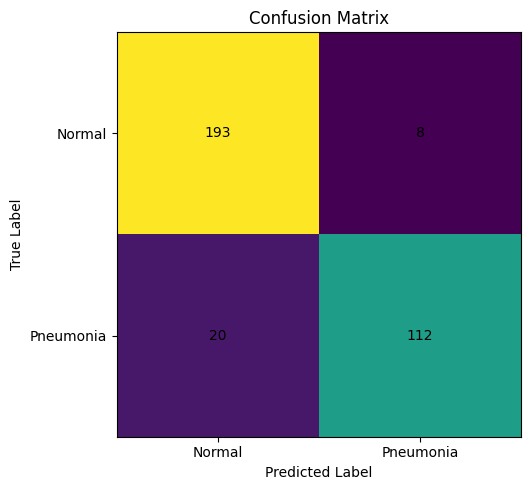

  Saved: confusion_matrix.png

  MEMORY USAGE
  GPU               : Not available (running on CPU)
  RAM Used (process): 747.86 MB
  RAM Total         : 12975.54 MB
  RAM Available     : 10469.17 MB
  RAM Usage         : 19.3%
  Model Size (.pth) : 1.72 MB


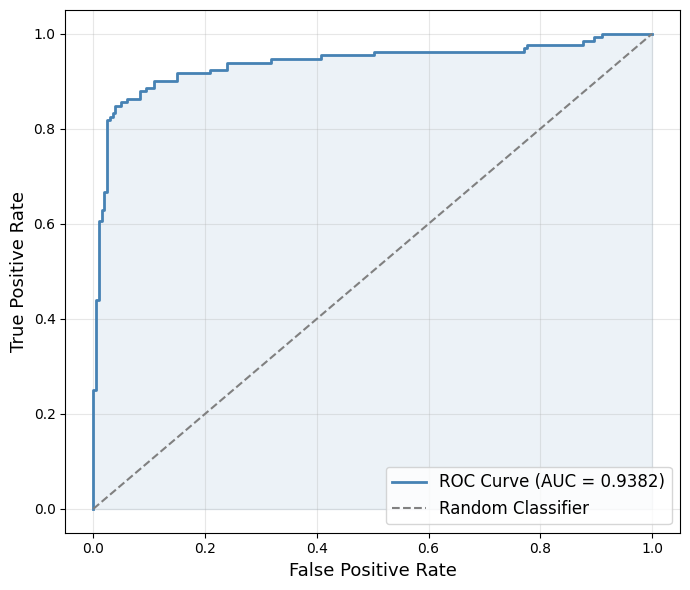

  Saved: roc_curve.png

  GradCAM target layer : Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  Class mapping : {'normal': 0, 'pneumonia': 1}


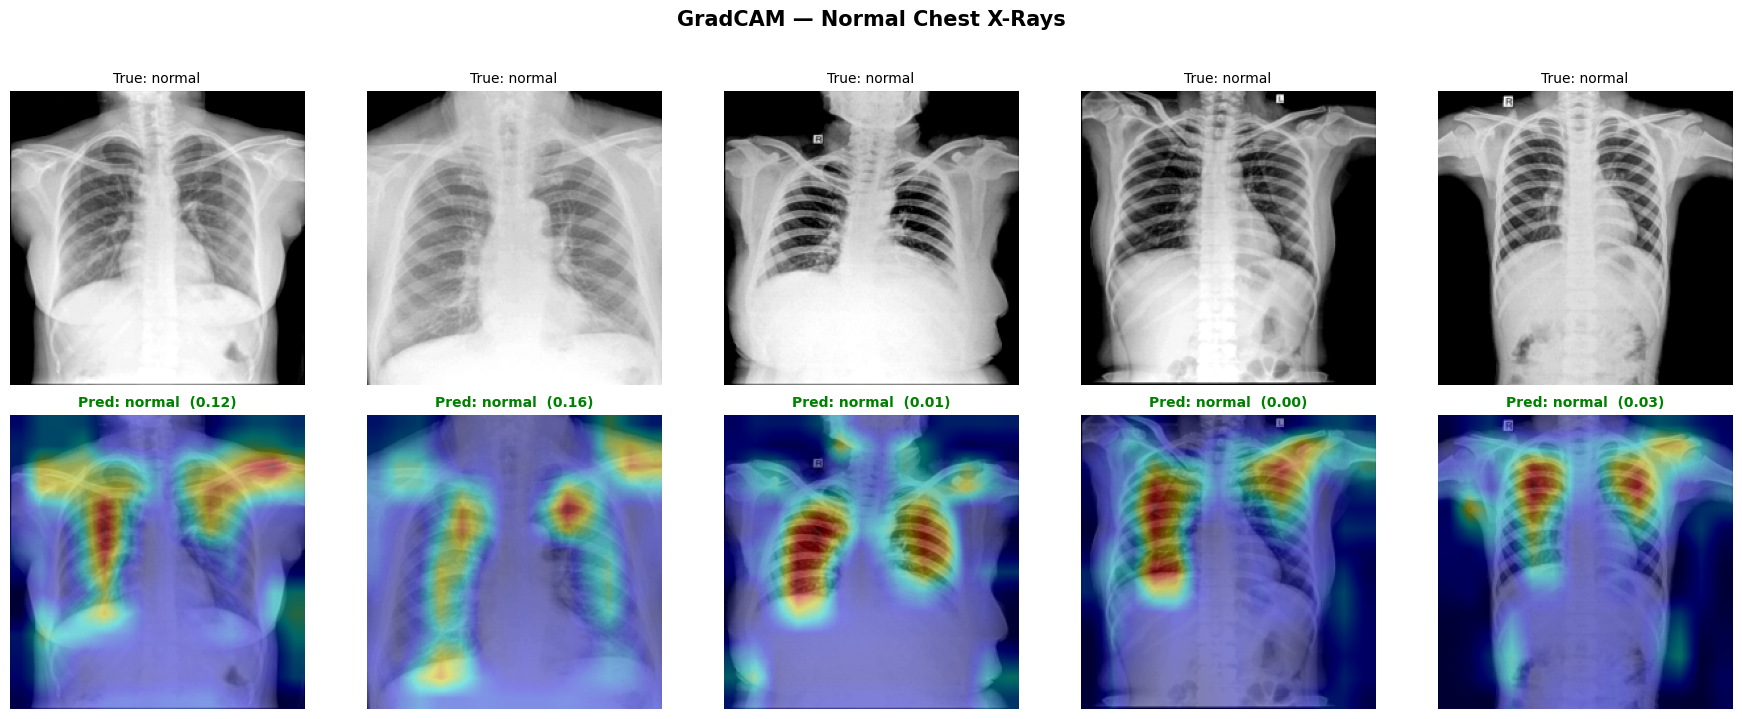

  Saved: gradcam_normal.png


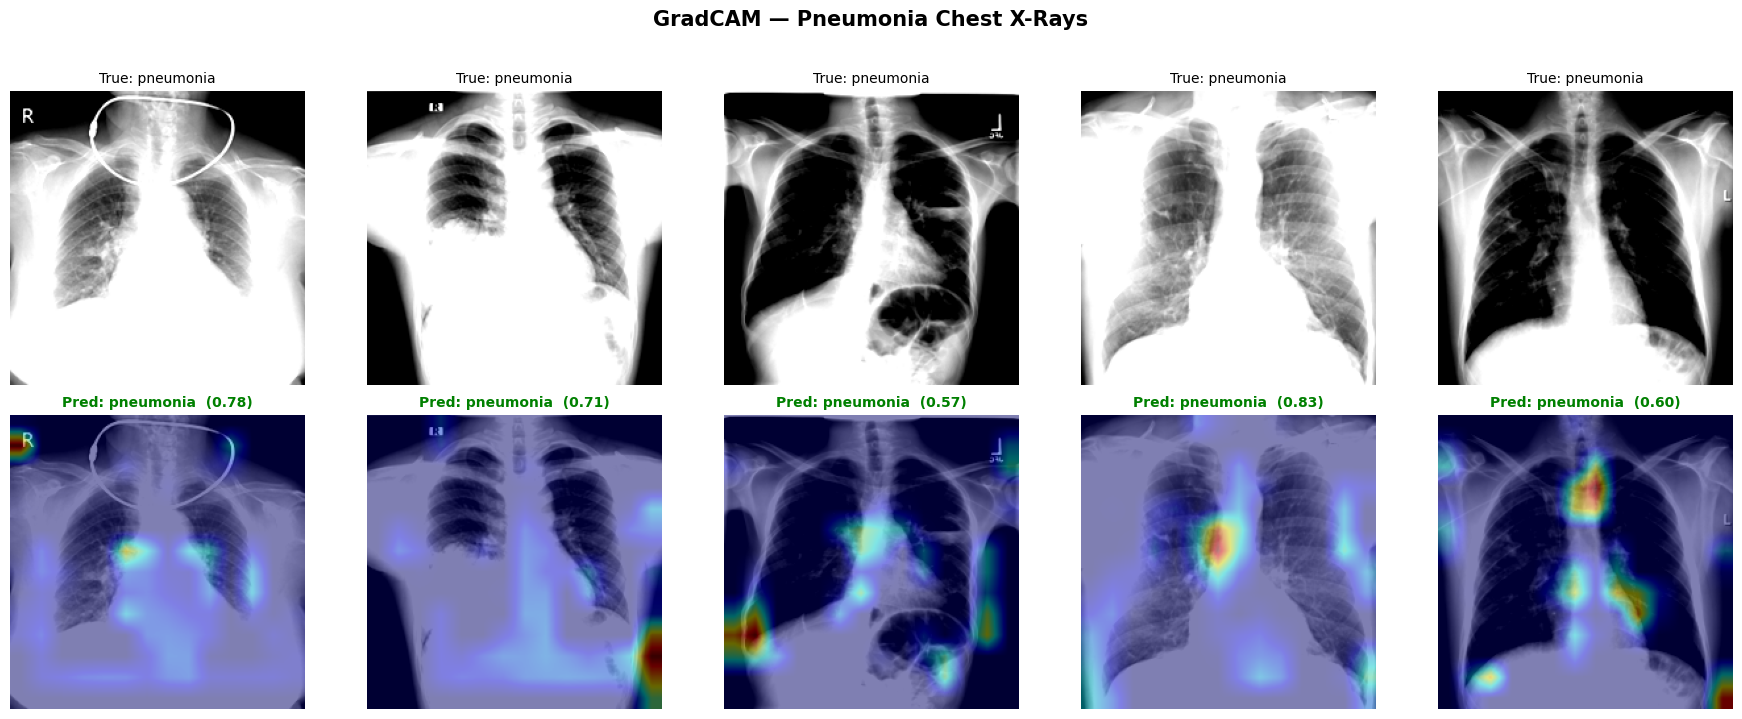

  Saved: gradcam_pneumonia.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from torchvision import datasets
import time
from timeit import default_timer as timer
import numpy as np
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import cv2
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, roc_curve)
from sklearn.metrics import confusion_matrix

import subprocess
try:
    import psutil
except ImportError:
    subprocess.run(['pip', 'install', 'psutil', '-q'])
    import psutil

# ─────────────────────────────────────────────
# TEST DATASET & DATALOADER
# ─────────────────────────────────────────────
test_dataset = datasets.ImageFolder(
    root=dst,
    transform=val_test_transforms
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print(f"  Test samples : {len(test_dataset)}")
print(f"  Classes      : {test_dataset.class_to_idx}")

# ─────────────────────────────────────────────
# INFERENCE
# ─────────────────────────────────────────────

THRESHOLD = 0.25

all_preds  = []
all_labels = []
all_probs  = []

start_time = time.perf_counter()
with torch.no_grad():
    for images, labels in test_dataloader:
        images  = images.to(device)
        outputs = loaded_model(images)
        probs   = torch.softmax(outputs, dim=1)[:, 1]
        preds   = (probs >= THRESHOLD).long()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
end_time = time.perf_counter()

# ─────────────────────────────────────────────
# METRICS — printed only, no chart
# ─────────────────────────────────────────────
total_images   = len(all_labels)
avg_latency_ms = (end_time - start_time) / total_images * 1000

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
try:
    roc_auc = roc_auc_score(all_labels, all_probs)
except:
    roc_auc = 0.0

print("\n" + "="*50)
print("  MODEL PERFORMANCE ON TEST SET")
print("="*50)
print(f"  Accuracy     : {accuracy*100:.2f}%")
print(f"  Precision    : {precision*100:.2f}%")
print(f"  Recall       : {recall*100:.2f}%")
print(f"  F1-Score     : {f1*100:.2f}%")
print(f"  ROC-AUC      : {roc_auc*100:.2f}%")
print(f"  Avg Latency  : {avg_latency_ms:.3f} ms/image")
print("="*50)

# ─────────────────────────────────────────────
# CONFUSION MATRIX  ← ADD HERE
# ─────────────────────────────────────────────
# from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*50)
print("  CONFUSION MATRIX")
print("="*50)
print(f"  True Negative (TN): {tn}")
print(f"  False Positive (FP): {fp}")
print(f"  False Negative (FN): {fn}")
print(f"  True Positive (TP): {tp}")
print("="*50)


# Plot
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Normal', 'Pneumonia'])
ax.set_yticklabels(['Normal', 'Pneumonia'])

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("  Saved: confusion_matrix.png")

# ─────────────────────────────────────────────
# MEMORY USAGE
# ─────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"  MEMORY USAGE")
print(f"{'='*50}")

# ── GPU Memory ────────────────────────────────
if torch.cuda.is_available():
    allocated   = torch.cuda.memory_allocated(device) / 1024**2
    reserved    = torch.cuda.memory_reserved(device)  / 1024**2
    max_alloc   = torch.cuda.max_memory_allocated(device) / 1024**2
    print(f"  GPU Allocated     : {allocated:.2f} MB")
    print(f"  GPU Reserved      : {reserved:.2f} MB")
    print(f"  GPU Peak Usage    : {max_alloc:.2f} MB")
else:
    print(f"  GPU               : Not available (running on CPU)")

# ── CPU / RAM Memory ──────────────────────────
import psutil
import os

process    = psutil.Process(os.getpid())
ram_usage  = process.memory_info().rss / 1024**2   # RSS = physical RAM used
ram_total  = psutil.virtual_memory().total / 1024**2
ram_avail  = psutil.virtual_memory().available / 1024**2
ram_pct    = psutil.virtual_memory().percent

print(f"  RAM Used (process): {ram_usage:.2f} MB")
print(f"  RAM Total         : {ram_total:.2f} MB")
print(f"  RAM Available     : {ram_avail:.2f} MB")
print(f"  RAM Usage         : {ram_pct:.1f}%")

# ── Model Size on Disk ────────────────────────
import os
model_size = os.path.getsize('smallresnet_final_using.pth') / 1024**2
print(f"  Model Size (.pth) : {model_size:.2f} MB")

print(f"{'='*50}")

# ─────────────────────────────────────────────
# ROC CURVE
# ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.5,
        linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Saved: roc_curve.png")

# ─────────────────────────────────────────────
# GRAD-CAM
# ─────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        pooled_grads = self.gradients.mean(dim=[0, 2, 3])
        cam = self.activations[0].clone()
        for i, w in enumerate(pooled_grads):
            cam[i] *= w

        cam = F.relu(cam.mean(dim=0))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = cam.cpu().numpy()

        return cam, class_idx


# ── Find last conv layer ──────────────────────
def get_last_conv_layer(model):
    last_conv = None
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
    return last_conv

target_layer = get_last_conv_layer(loaded_model)
grad_cam     = GradCAM(loaded_model, target_layer)
print(f"\n  GradCAM target layer : {target_layer}")

# ─────────────────────────────────────────────
# COLLECT 5 NORMAL + 5 PNEUMONIA SAMPLES
# ─────────────────────────────────────────────
print(f"  Class mapping : {test_dataset.class_to_idx}")

normal_idx    = test_dataset.class_to_idx.get(
    'normal', test_dataset.class_to_idx.get('NORMAL', 0))
pneumonia_idx = test_dataset.class_to_idx.get(
    'pneumonia', test_dataset.class_to_idx.get('PNEUMONIA', 1))

normal_samples    = []
pneumonia_samples = []

for idx, (img_path, label) in enumerate(test_dataset.samples):
    if label == normal_idx    and len(normal_samples)    < 5:
        normal_samples.append(idx)
    if label == pneumonia_idx and len(pneumonia_samples) < 5:
        pneumonia_samples.append(idx)
    if len(normal_samples) == 5 and len(pneumonia_samples) == 5:
        break

# ─────────────────────────────────────────────
# GRAD-CAM PLOT FUNCTION
# ─────────────────────────────────────────────
# def plot_gradcam_grid(sample_indices, dataset, grad_cam,
#                       title, filename):
#     fig, axes = plt.subplots(2, 5, figsize=(18, 7))
#     fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

#     class_names = {v: k for k, v in dataset.class_to_idx.items()}

#     for col, idx in enumerate(sample_indices):
#         img_tensor, label = dataset[idx]
#         input_tensor = img_tensor.unsqueeze(0).to(device)

#         cam, pred_class = grad_cam.generate(input_tensor)

#         img_np = img_tensor.squeeze().cpu().numpy()
#         img_np = (img_np * 0.5) + 0.5
#         img_np = np.clip(img_np, 0, 1)

#         cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
#         heatmap     = cv2.applyColorMap(
#             np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
#         heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

#         img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
#         overlay = 0.5 * img_rgb + 0.4 * heatmap
#         overlay = np.clip(overlay, 0, 1)

#         pred_label = class_names[pred_class]
#         true_label = class_names[label]
#         color      = 'green' if pred_class == label else 'red'

#         axes[0, col].imshow(img_np, cmap='gray')
#         axes[0, col].set_title(f'True: {true_label}', fontsize=10)
#         axes[0, col].axis('off')

#         axes[1, col].imshow(overlay)
#         axes[1, col].set_title(f'Pred: {pred_label}',
#                                fontsize=10, color=color,
#                                fontweight='bold')
#         axes[1, col].axis('off')

#     axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
#     axes[1, 0].set_ylabel('GradCAM',  fontsize=11, fontweight='bold')

#     plt.tight_layout()
#     plt.savefig(filename, dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"  Saved: {filename}")

def plot_gradcam_grid(sample_indices, dataset, grad_cam,
                      title, filename, threshold=THRESHOLD):   # ← added threshold
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    class_names = {v: k for k, v in dataset.class_to_idx.items()}

    for col, idx in enumerate(sample_indices):
        img_tensor, label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        # ── threshold-aware class index ───────────────────
        with torch.no_grad():
            out   = loaded_model(input_tensor)
            prob  = torch.softmax(out, dim=1)[0, 1].item()
        class_idx = 1 if prob >= threshold else 0
        # ─────────────────────────────────────────────────

        cam, pred_class = grad_cam.generate(input_tensor,
                                            class_idx=class_idx)  # ← explicit

        img_np = img_tensor.squeeze().cpu().numpy()
        img_np = (img_np * 0.5) + 0.5
        img_np = np.clip(img_np, 0, 1)

        cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        heatmap     = cv2.applyColorMap(
            np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
        heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

        img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
        overlay = 0.5 * img_rgb + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)

        pred_label = class_names[pred_class]
        true_label = class_names[label]
        color      = 'green' if pred_class == label else 'red'

        axes[0, col].imshow(img_np, cmap='gray')
        axes[0, col].set_title(f'True: {true_label}', fontsize=10)
        axes[0, col].axis('off')

        axes[1, col].imshow(overlay)
        axes[1, col].set_title(f'Pred: {pred_label}  ({prob:.2f})',  # ← shows prob
                               fontsize=10, color=color, fontweight='bold')
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=11, fontweight='bold')
    axes[1, 0].set_ylabel('GradCAM',  fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved: {filename}")

# ─────────────────────────────────────────────
# PLOT — NORMAL & PNEUMONIA
# ─────────────────────────────────────────────
plot_gradcam_grid(
    sample_indices = normal_samples,
    dataset        = test_dataset,
    grad_cam       = grad_cam,
    title          = 'GradCAM — Normal Chest X-Rays',
    filename       = 'gradcam_normal.png'
)

plot_gradcam_grid(
    sample_indices = pneumonia_samples,
    dataset        = test_dataset,
    grad_cam       = grad_cam,
    title          = 'GradCAM — Pneumonia Chest X-Rays',
    filename       = 'gradcam_pneumonia.png'
)

# ─────────────────────────────────────────────
# DOWNLOAD ALL
# ─────────────────────────────────────────────
from google.colab import files
for f_name in ['roc_curve.png', 'gradcam_normal.png', 'gradcam_pneumonia.png']:
    files.download(f_name)

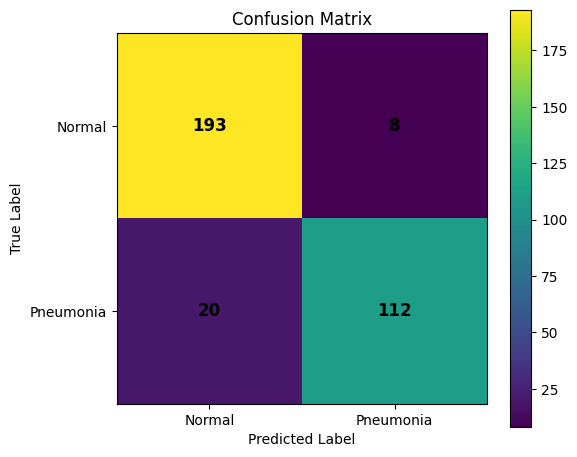

Saved: confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm)

# Labels
classes = ['Normal', 'Pneumonia']
ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                fontsize=12, fontweight='bold')

# Colorbar (optional but good for thesis)
fig.colorbar(im)

plt.tight_layout()

# Save high-quality image
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

plt.show()

print("Saved: confusion_matrix.png")

In [ ]:
from google.colab import files
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>